[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-1/chain.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58238466-lesson-4-chain)

# Chain

## Review

We built a simple graph with nodes, normal edges, and conditional edges.

## Goals

Now, let's build up to a simple chain that combines 4 concepts.

* Using [chat messages](https://docs.langchain.com/oss/python/langchain/messages) as our graph state
* Using [chat models](https://docs.langchain.com/oss/python/integrations/chat) in graph nodes
* [Binding tools](https://docs.langchain.com/oss/python/langchain/models#tool-calling) to our chat model
* [Executing tool calls](https://docs.langchain.com/oss/python/langchain/models#tool-execution-loop) in graph nodes 

![Screenshot 2024-08-21 at 9.24.03 AM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dd607b08df5e1101_chain1.png)

In [23]:
%%capture --no-stderr
%pip install --quiet -U langchain_ollama langchain_core langgraph


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Messages

Chat models can use [messages](https://docs.langchain.com/oss/python/langchain/messages), which capture different roles within a conversation. 

LangChain supports various message types, including `HumanMessage`, `AIMessage`, `SystemMessage`, and `ToolMessage`. 

These represent a message from the user, from chat model, for the chat model to instruct behavior, and from a tool call. 

Let's create a list of messages. 

Each message can be supplied with a few things:

* `content` - content of the message
* `name` - optionally, a message author 
* `response_metadata` - optionally, a dict of metadata (e.g., often populated by model provider for `AIMessages`)

In [24]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage

messages = [AIMessage(content=f"So you said you were researching ocean mammals?", name="Model")]
messages.append(HumanMessage(content=f"Yes, that's right.",name="Pau"))
messages.append(AIMessage(content=f"Great, what would you like to learn about.", name="Model"))
messages.append(HumanMessage(content=f"I want to learn about the best place to see Orcas in the world.", name="Pau"))

for m in messages:
    m.pretty_print()

================================== Ai Message ==================================
Name: Model

So you said you were researching ocean mammals?
================================ Human Message =================================
Name: Pau

Yes, that's right.
================================== Ai Message ==================================
Name: Model

Great, what would you like to learn about.
================================ Human Message =================================
Name: Pau

I want to learn about the best place to see Orcas in the world.


## Chat Models

Chat models use a sequence of messages as input and support message types, as discussed above.

There are [many](https://docs.langchain.com/oss/python/integrations/chat) to choose from! Let's work with OpenAI. 

Let's check that your `OPENAI_API_KEY` is set and, if not, you will be asked to enter it.

We can load a chat model and invoke it with out list of messages.

We can see that the result is an `AIMessage` with specific `response_metadata`.

In [25]:
from langchain_ollama import ChatOllama
llm = ChatOllama(model="llama3.2", temperature=0)
result = llm.invoke(messages)
type(result)

langchain_core.messages.ai.AIMessage

In [26]:
result.pretty_print()

================================== Ai Message ==================================

Orcas, also known as killer whales, are a fascinating species. There are several locations around the world where you can see Orcas in their natural habitat. Here are some of the best places to see Orcas:

1. **Puget Sound, Washington, USA**: This is one of the most popular places to see Orcas, particularly the Southern Resident pods. The sound is home to a large population of Orcas, and you can take guided tours or kayak to get up close to these magnificent creatures.
2. **Resurrection Bay, Alaska, USA**: Located near Seward, Alaska, Resurrection Bay is a hotspot for Orcas. The bay is a feeding ground for the Orcas, and you can take a boat tour to see them in their natural habitat.
3. **Tonga Islands, South Pacific**: The Tonga Islands are home to a large population of Bottlenose Orcas. The islands are a popular spot for whale watching, and you can take a boat tour to see the Orcas in their natural habit

In [27]:
result.response_metadata

{'model': 'llama3.2',
 'created_at': '2026-10-02T15:06:10.9883999Z',
 'done': True,
 'done_reason': 'stop',
 'total_duration': 28323720200,
 'load_duration': 6159300,
 'prompt_eval_count': 81,
 'prompt_eval_duration': 1209827000,
 'eval_count': 425,
 'eval_duration': 27088133000,
 'logprobs': None,
 'model_name': 'llama3.2',
 'model_provider': 'ollama'}

## Tools

Tools are useful whenever you want a model to interact with external systems.

External systems (e.g., APIs) often require a particular input schema or payload, rather than natural language. 

When we bind an API, for example, as a tool we given the model awareness of the required input schema.

The model will choose to call a tool based upon the natural language input from the user. 

And, it will return an output that adheres to the tool's schema. 

[Many LLM providers support tool calling](https://docs.langchain.com/oss/python/integrations/chat) and [tool calling interface](https://blog.langchain.com/improving-core-tool-interfaces-and-docs-in-langchain/) in LangChain is simple. 
 
You can simply pass any Python `function` into `ChatModel.bind_tools(function)`.

![Screenshot 2024-08-19 at 7.46.28 PM.png](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66dbab08dc1c17a7a57f9960_chain2.png)

Let's showcase a simple example of tool calling!
 
The `multiply` function is our tool.

In [28]:
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

llm_with_tools = llm.bind_tools([multiply])

If we pass an input - e.g., `"What is 2 multiplied by 3"` - we see a tool call returned. 

The tool call has specific arguments that match the input schema of our function along with the name of the function to call.

```
{'arguments': '{"a":2,"b":3}', 'name': 'multiply'}
```

In [29]:
tool_call = llm_with_tools.invoke([HumanMessage(content=f"What is 7 multiplied by 19", name="Pau")])

In [30]:
tool_call.tool_calls

[{'name': 'multiply',
  'args': {'a': 7, 'b': 19},
  'id': '7e834a0f-5485-4117-b865-0efd70f5deaa',
  'type': 'tool_call'}]

## Using messages as state

With these foundations in place, we can now use  [messages](https://docs.langchain.com/oss/python/langchain/overview#messages) in our graph state.

Let's define our state, `MessagesState`, as a `TypedDict` with a single key: `messages`.

`messages` is simply a list of messages, as we defined above (e.g., `HumanMessage`, etc).

In [31]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage

class MessagesState(TypedDict):
    messages: list[AnyMessage]

## Reducers

Now, we have a minor problem! 

As we discussed, each node will return a new value for our state key `messages`.

But, this new value will overwrite the prior `messages` value!
 
As our graph runs, we want to **append** messages to our `messages` state key.
 
We can use [reducer functions](https://docs.langchain.com/oss/python/langgraph/graph-api#reducers) to address this.

Reducers specify how state updates are performed.

If no reducer function is specified, then it is assumed that updates to the key should *override it* as we saw before.
 
But, to append messages, we can use the pre-built `add_messages` reducer.

This ensures that any messages are appended to the existing list of messages.

We simply need to annotate our `messages` key with the `add_messages` reducer function as metadata.

In [32]:
from typing import Annotated
from langgraph.graph.message import add_messages

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

Since having a list of messages in graph state is so common, LangGraph has a pre-built  [`MessagesState`](https://docs.langchain.com/oss/python/langgraph/graph-api#messagesstate)! 

`MessagesState` is defined: 

* With a pre-build single `messages` key
* This is a list of `AnyMessage` objects 
* It uses the `add_messages` reducer

We'll usually use `MessagesState` because it is less verbose than defining a custom `TypedDict`, as shown above.

In [33]:
from langgraph.graph import MessagesState

class MessagesState(MessagesState):
    # Add any keys needed beyond messages, which is pre-built 
    pass

To go a bit deeper, we can see how the `add_messages` reducer works in isolation.

In [34]:
# Initial state
initial_messages = [AIMessage(content="Hello! How can I assist you?", name="Model"),
                    HumanMessage(content="I'm looking for information on marine biology.", name="Pau")
                   ]

# New message to add
new_message = AIMessage(content="Sure, I can help with that. What specifically are you interested in?", name="Model")

# Test
add_messages(initial_messages , new_message)

[AIMessage(content='Hello! How can I assist you?', additional_kwargs={}, response_metadata={}, name='Model', id='62d7b190-9585-47ad-824e-fe294c31ccb5', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content="I'm looking for information on marine biology.", additional_kwargs={}, response_metadata={}, name='Pau', id='7d695154-567a-4496-a65d-0d43f017067e'),
 AIMessage(content='Sure, I can help with that. What specifically are you interested in?', additional_kwargs={}, response_metadata={}, name='Model', id='2708cb0d-0493-494e-bbcc-7f6cdfcf16bb', tool_calls=[], invalid_tool_calls=[])]

## Our graph

Now, lets use `MessagesState` with a graph.

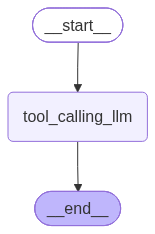

In [35]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
    
# Node
def tool_calling_llm(state: MessagesState):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_edge(START, "tool_calling_llm")
builder.add_edge("tool_calling_llm", END)
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

If we pass in `Hello!`, the LLM responds without any tool calls.

In [49]:
messages = graph.invoke({"messages": HumanMessage(content="Hello! What is the capital of the US?")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello! What is the capital of the US?
================================== Ai Message ==================================
Tool Calls:
  multiply (7c36f373-b5d5-4174-80f5-0a408b6fc81b)
 Call ID: 7c36f373-b5d5-4174-80f5-0a408b6fc81b
  Args:
    a: 0
    b: 0


In [50]:
response = llm_with_tools.invoke("Hello! What is the capital of the US?")
print(response)

content='' additional_kwargs={} response_metadata={'model': 'llama3.2', 'created_at': '2026-10-02T15:28:01.5140755Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1106597700, 'load_duration': 6602300, 'prompt_eval_count': 174, 'prompt_eval_duration': 89386000, 'eval_count': 16, 'eval_duration': 1003341000, 'logprobs': None, 'model_name': 'llama3.2', 'model_provider': 'ollama'} id='lc_run--01a0fd3a-bd95-74b3-8d7c-88e18ebbdbba-0' tool_calls=[{'name': 'multiply', 'args': {'a': '0', 'b': '0'}, 'id': '85be6d94-e91e-454f-8c07-4c1b1cd8225c', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 174, 'output_tokens': 16, 'total_tokens': 190}


The LLM chooses to use a tool when it determines that the input or task requires the functionality provided by that tool.

In [46]:
messages = graph.invoke({"messages": HumanMessage(content="Multiply 5 and 7")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Multiply 5 and 7
================================== Ai Message ==================================
Tool Calls:
  multiply (11a15f97-f8e7-4e01-be16-18bbe5c21a44)
 Call ID: 11a15f97-f8e7-4e01-be16-18bbe5c21a44
  Args:
    a: 5
    b: 7
